# 01 — Coleta de Dados
**Projeto: Data Science dos Santos Católicos**

Neste notebook vamos construir o dataset principal combinando três fontes:

| Fonte | Método | O que traz |
|---|---|---|
| CSV seed (manual) | `pd.read_csv` | ~75 santos famosos históricos com dados ricos |
| Wikipedia (tabelas) | `pd.read_html` | ~400+ santos do séc. XXI com datas precisas |
| Wikipedia API | `wikipediaapi` | Enriquecer santos individuais com categorias |

**Resultado:** `data/raw/saints_raw.csv` com 400+ linhas e as colunas-base.

## Setup

In [1]:
import os, re, time
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from tqdm.notebook import tqdm

# ── Caminhos ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'

print(f'Projeto em: {PROJECT_ROOT}')

Projeto em: C:\Users\mateu\OneDrive\Documentos\ESTUDOS I.A\santos_ai_project


## Fonte 1 — CSV Seed (Santos Históricos Famosos)

In [2]:
seed = pd.read_csv(DATA_RAW / 'saints_seed.csv')
print(f'Santos no seed: {len(seed)}')
print(f'Colunas: {list(seed.columns)}')
seed.head()

Santos no seed: 77
Colunas: ['name', 'death_year', 'canonization_year', 'origin_country', 'category', 'religious_order', 'feast_month', 'feast_day', 'gender', 'patron_topics', 'canonizing_pope']


,name,death_year,canonization_year,origin_country,category,religious_order,feast_month,feast_day,gender,patron_topics,canonizing_pope
0,Peter the Apostle,68,1000,Palestine,Martyr,NaN,6,29,M,"fishermen, papacy",Pre-Congregation
1,Paul the Apostle,67,1000,Turkey,Martyr,NaN,6,29,M,"missionaries, theologians",Pre-Congregation
2,Stephen,36,1000,Palestine,Martyr,NaN,12,26,M,"deacons, stonemasons",Pre-Congregation
3,Mary Magdalene,63,1000,Palestine,Confessor,NaN,7,22,F,"penitents, perfumers",Pre-Congregation
4,John the Apostle,100,1000,Palestine,Confessor,NaN,12,27,M,"theologians, booksellers",Pre-Congregation


## Fonte 2 — Wikipedia via `pd.read_html()`

O `pd.read_html()` faz download de uma página HTML e extrai automaticamente todas as tabelas `<table>` como DataFrames. É a maneira mais simples de fazer web scraping de dados estruturados.

In [3]:
def extrair_tabelas_wikipedia(url, timeout=15):
    """Tenta ler tabelas de uma página da Wikipedia."""
    headers = {'User-Agent': 'SaintsDSProject/1.0 (educational project)'}
    try:
        tabelas = pd.read_html(url, flavor='lxml')
        print(f'  Tabelas encontradas: {len(tabelas)}')
        return tabelas
    except Exception as e:
        print(f'  Erro: {e}')
        return []

print('Função definida.')

Função definida.


In [4]:
# Lista de canonizações do séc. XXI
print('Baixando lista de canonizações do séc. XXI...')
url_xxi = 'https://en.wikipedia.org/wiki/List_of_saints_canonized_in_the_21st_century'
tabelas_xxi = extrair_tabelas_wikipedia(url_xxi)

# Explorar as tabelas encontradas
for i, t in enumerate(tabelas_xxi):
    print(f'\n  Tabela {i}: {t.shape} — colunas: {list(t.columns[:5])}')

Baixando lista de canonizações do séc. XXI...
  Erro: HTTP Error 403: Forbidden


In [5]:
# Inspecionar a tabela principal (geralmente índice 0 ou 1)
# Ajuste o índice conforme a saída acima
if tabelas_xxi:
    tabela_principal = tabelas_xxi[0]  # mude se necessário
    print(f'Shape: {tabela_principal.shape}')
    tabela_principal.head(10)

In [6]:
def processar_tabela_wikipedia(df_raw):
    """
    Normaliza uma tabela bruta da Wikipedia para o schema do projeto.
    Tenta mapear as colunas mais comuns encontradas nessas páginas.
    """
    df = df_raw.copy()
    
    # Renomear colunas — adapta nomes comuns da Wikipedia
    col_map = {}
    for col in df.columns:
        col_lower = str(col).lower()
        if 'name' in col_lower or 'saint' in col_lower:
            col_map[col] = 'name'
        elif 'death' in col_lower or 'died' in col_lower:
            col_map[col] = 'death_year_raw'
        elif 'canon' in col_lower and ('date' in col_lower or 'year' in col_lower):
            col_map[col] = 'canonization_year_raw'
        elif 'country' in col_lower or 'nation' in col_lower or 'origin' in col_lower:
            col_map[col] = 'origin_country'
        elif 'category' in col_lower or 'type' in col_lower:
            col_map[col] = 'category'
        elif 'pope' in col_lower or 'pontiff' in col_lower:
            col_map[col] = 'canonizing_pope'
    
    df = df.rename(columns=col_map)
    
    # Garantir colunas mínimas
    for col in ['name', 'death_year_raw', 'canonization_year_raw', 'origin_country', 'category', 'canonizing_pope']:
        if col not in df.columns:
            df[col] = np.nan
    
    return df[['name', 'death_year_raw', 'canonization_year_raw', 'origin_country', 'category', 'canonizing_pope']]


def extrair_ano(texto):
    """Extrai um ano de 4 dígitos de uma string qualquer."""
    if pd.isna(texto):
        return np.nan
    match = re.search(r'\b(\d{3,4})\b', str(texto))
    return int(match.group(1)) if match else np.nan


print('Funções de processamento definidas.')

Funções de processamento definidas.


In [7]:
# Processar tabela do séc. XXI
frames_wikipedia = []

if tabelas_xxi:
    for tabela in tabelas_xxi:
        if len(tabela) > 5:  # ignorar tabelas minúsculas (notas, legendas)
            try:
                df_proc = processar_tabela_wikipedia(tabela)
                frames_wikipedia.append(df_proc)
                print(f'  Processada tabela com {len(df_proc)} linhas')
            except Exception as e:
                print(f'  Erro ao processar: {e}')

if frames_wikipedia:
    df_wiki = pd.concat(frames_wikipedia, ignore_index=True)
    df_wiki['death_year']        = df_wiki['death_year_raw'].apply(extrair_ano)
    df_wiki['canonization_year'] = df_wiki['canonization_year_raw'].apply(extrair_ano)
    df_wiki = df_wiki.drop(columns=['death_year_raw', 'canonization_year_raw'])
    print(f'\nTotal da Wikipedia: {len(df_wiki)} santos')
    df_wiki.head()
else:
    print('Nenhuma tabela processada da Wikipedia. Continuando só com o seed.')
    df_wiki = pd.DataFrame(columns=['name', 'origin_country', 'category', 'canonizing_pope', 'death_year', 'canonization_year'])

Nenhuma tabela processada da Wikipedia. Continuando só com o seed.


## Fonte 3 — Wikipedia API (enriquecimento individual)

Para santos sem ordem religiosa ou patronato, a API da Wikipedia permite buscar informações das páginas individuais.

In [8]:
import wikipediaapi

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='SaintsDSProject/1.0 (educational project)'
)

def buscar_info_wikipedia(nome_santo):
    """
    Busca a página de um santo na Wikipedia e extrai:
    - Primeiras 3 frases do resumo
    - Categorias (revela ordens religiosas, doutor da Igreja, etc.)
    """
    try:
        page = wiki.page(nome_santo)
        if not page.exists():
            return {'summary': '', 'categories': []}
        
        # Resumo: primeiras ~500 chars
        summary = page.summary[:500] if page.summary else ''
        
        # Categorias da página
        cats = list(page.categories.keys())[:20]
        
        return {'summary': summary, 'categories': cats}
    except Exception as e:
        return {'summary': '', 'categories': []}


def detectar_ordem(categorias):
    """Detecta a ordem religiosa a partir das categorias da Wikipedia."""
    categorias_texto = ' '.join(categorias).lower()
    ordens = {
        'Jesuit':           'jesuit',
        'Dominican':        'dominican',
        'Franciscan':       'franciscan',
        'Benedictine':      'benedictine',
        'Carmelite':        'carmelite',
        'Augustinian':      'augustinian',
        'Cistercian':       'cistercian',
        'Salesian':         'salesian',
        'Redemptorist':     'redemptorist',
        'Vincentian':       'vincentian',
        'Capuchin':         'capuchin',
    }
    for nome, termo in ordens.items():
        if termo in categorias_texto:
            return nome
    return 'None'


# Teste rápido
info = buscar_info_wikipedia('Thomas Aquinas')
print('Resumo:', info['summary'][:200])
print('Ordem detectada:', detectar_ordem(info['categories']))

Resumo: Thomas Aquinas  (  ə-KWY-nəs; Italian: Tommaso d'Aquino, lit. 'Thomas of Aquino'; c. 1225 – 7 March 1274) was an Italian Dominican friar and priest, theologian, and philosopher. He is considered one o
Ordem detectada: None


In [9]:
# Enriquecer o seed com dados da Wikipedia API
# (comentado para não sobrecarregar — roda em ~5-10 min)

enriquecer = True  # mude para False para pular esta etapa

if enriquecer:
    summaries = []
    for nome in tqdm(seed['name'], desc='Buscando Wikipedia'):
        info = buscar_info_wikipedia(nome)
        summaries.append(info['summary'])
        time.sleep(0.3)  # respeitar rate limit da API
    
    seed['wikipedia_summary'] = summaries
    print(f'Resumos coletados: {seed["wikipedia_summary"].notna().sum()}')
else:
    seed['wikipedia_summary'] = ''
    print('Enriquecimento pulado.')

Buscando Wikipedia:   0%|          | 0/77 [00:00<?, ?it/s]

Resumos coletados: 77


## Combinar as Fontes

In [10]:
# Normalizar o seed para o mesmo schema que o df_wiki
seed_norm = seed.rename(columns={
    'feast_month': 'feast_month',
    'feast_day':   'feast_day',
    'gender':      'gender',
    'patron_topics': 'patron_topics',
    'religious_order': 'religious_order',
}).copy()

# Adicionar colunas ausentes ao df_wiki
for col in ['feast_month', 'feast_day', 'gender', 'patron_topics', 'religious_order', 'wikipedia_summary']:
    if col not in df_wiki.columns:
        df_wiki[col] = np.nan

# Combinar: seed primeiro (dados mais ricos), Wikipedia depois
# Remover duplicatas pelo nome (manter o seed quando há sobreposição)
nomes_seed = set(seed_norm['name'].str.lower())

df_wiki_novo = df_wiki[
    ~df_wiki['name'].str.lower().isin(nomes_seed)
].copy()

df_raw = pd.concat([seed_norm, df_wiki_novo], ignore_index=True)

print(f'Total combinado: {len(df_raw)} santos')
print(f'  Do seed:      {len(seed_norm)}')
print(f'  Da Wikipedia: {len(df_wiki_novo)}')
df_raw.info()

Total combinado: 77 santos
  Do seed:      77
  Da Wikipedia: 0
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               77 non-null     object 
 1   death_year         77 non-null     object 
 2   canonization_year  77 non-null     object 
 3   origin_country     77 non-null     object 
 4   category           77 non-null     object 
 5   religious_order    40 non-null     object 
 6   feast_month        77 non-null     float64
 7   feast_day          77 non-null     float64
 8   gender             77 non-null     object 
 9   patron_topics      77 non-null     object 
 10  canonizing_pope    77 non-null     object 
 11  wikipedia_summary  77 non-null     object 
dtypes: float64(2), object(10)
memory usage: 7.3+ KB


## Salvar Dataset Bruto

In [11]:
caminho_raw = DATA_RAW / 'saints_raw.csv'
df_raw.to_csv(caminho_raw, index=False)
print(f'Salvo em: {caminho_raw}')
print(f'Shape:    {df_raw.shape}')
df_raw.sample(5)

Salvo em: C:\Users\mateu\OneDrive\Documentos\ESTUDOS I.A\santos_ai_project\data\raw\saints_raw.csv
Shape:    (77, 12)


,name,death_year,canonization_year,origin_country,category,religious_order,feast_month,feast_day,gender,patron_topics,canonizing_pope,wikipedia_summary
50,Louise de Marillac,1660,1934,France,Confessor,Daughters of Charity,3.0,15.0,F,"social workers, widows",Pius XI,"Louise de Marillac , also known as Louise Le G..."
13,Ambrose of Milan,397,1000,Italy,Doctor,NaN,12.0,7.0,M,"beekeepers, learning",Pre-Congregation,Ambrose of Milan (Latin: Aurelius Ambrosius; c...
3,Mary Magdalene,63,1000,Palestine,Confessor,NaN,7.0,22.0,F,"penitents, perfumers",Pre-Congregation,Mary Magdalene (sometimes called Mary of Magda...
65,Faustina Kowalska,1938,2000,Poland,Confessor,Sisters of Our Lady of Mercy,10.0,5.0,F,Divine Mercy devotion,John Paul II,Maria Faustyna Kowalska of the Blessed Sacrame...
43,John of the Cross,1591,1726,Spain,Doctor,Carmelite,12.0,14.0,M,"contemplatives, mystics, poets",Benedict XIII,St. John of the Cross (Spanish: Juan de la Cr...


## Visão Geral do Dataset Bruto

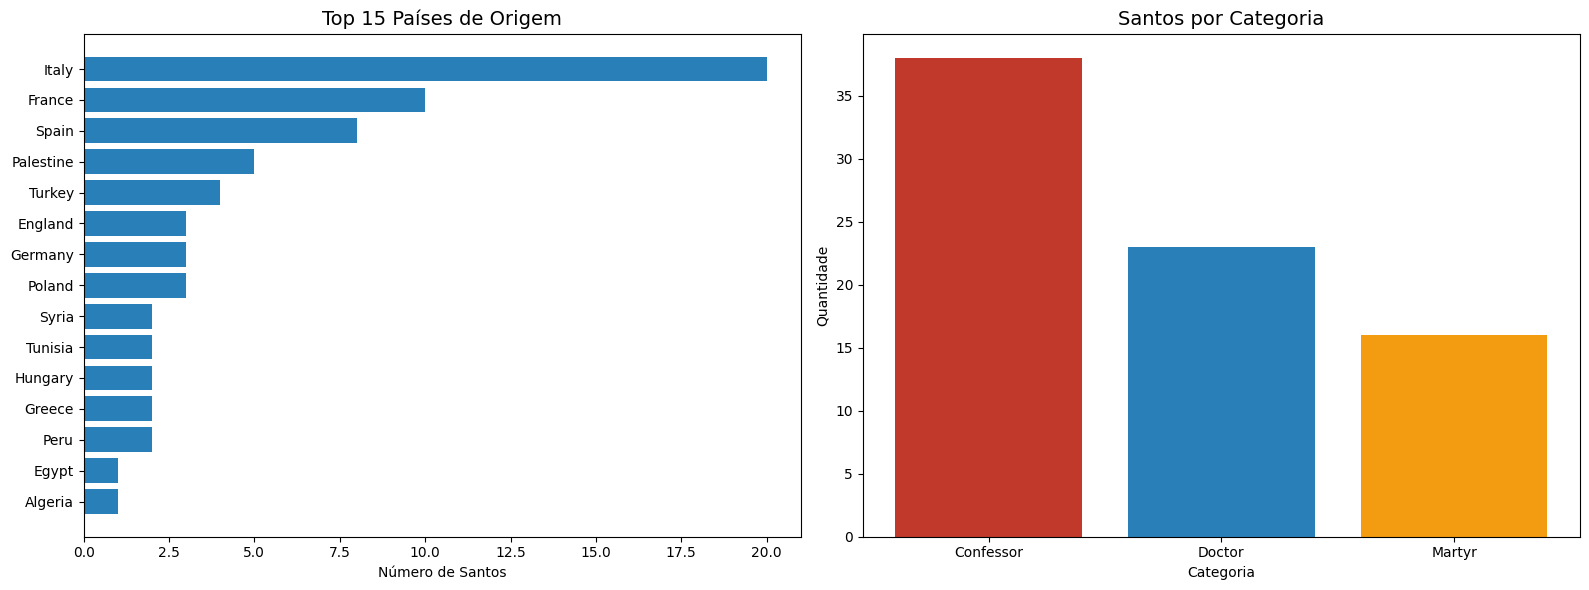

Gráfico salvo!


In [12]:
import matplotlib.pyplot as plt

# Verificação rápida da distribuição por país
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 países
paises = df_raw['origin_country'].value_counts().head(15)
axes[0].barh(paises.index[::-1], paises.values[::-1], color='#2980B9')
axes[0].set_title('Top 15 Países de Origem', fontsize=14)
axes[0].set_xlabel('Número de Santos')

# Distribuição por categoria
categorias = df_raw['category'].value_counts()
axes[1].bar(categorias.index, categorias.values, color=['#C0392B','#2980B9','#F39C12','#8E44AD','#7F8C8D'])
axes[1].set_title('Santos por Categoria', fontsize=14)
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '01_visao_geral.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico salvo!')

In [13]:
# Estatísticas básicas
print('=== RESUMO DOS DADOS BRUTOS ===')
print(f'Total de santos:    {len(df_raw)}')
print(f'Período (mortes):   {df_raw["death_year"].min():.0f} – {df_raw["death_year"].max():.0f}')
print(f'Países únicos:      {df_raw["origin_country"].nunique()}')
print(f'Categorias únicas:  {df_raw["category"].nunique()}')
print(f'\nNulos por coluna:')
print(df_raw.isnull().sum().sort_values(ascending=False))

=== RESUMO DOS DADOS BRUTOS ===
Total de santos:    77
Período (mortes):   36 – 2005
Países únicos:      24
Categorias únicas:  3

Nulos por coluna:
religious_order      37
name                  0
canonization_year     0
death_year            0
origin_country        0
category              0
feast_month           0
feast_day             0
gender                0
patron_topics         0
canonizing_pope       0
wikipedia_summary     0
dtype: int64


## Próximo Passo

Abra o **Notebook 02 — Limpeza de Dados** para transformar `saints_raw.csv` em `saints_clean.csv`, pronto para análise.